# Uber Fare Data Analysis
Exploratory data analysis and cleaning of the Uber fares dataset.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [3]:
df = pd.read_csv("uber.csv")
df.head()  # first 5 rows

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


## Removing Unnamed & Key Columns

In [4]:
# removing the un-named index column
df = df.drop(df.columns[0], axis=1)

# removing the key column
df = df.drop('key', axis=1)
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


## Data Info & Statistics

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        200000 non-null  float64
 1   pickup_datetime    200000 non-null  str    
 2   pickup_longitude   200000 non-null  float64
 3   pickup_latitude    200000 non-null  float64
 4   dropoff_longitude  199999 non-null  float64
 5   dropoff_latitude   199999 non-null  float64
 6   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 10.7 MB


In [6]:
df.describe()  # Statistics

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [7]:
df.isnull().sum()  # counting the NaN data

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [8]:
df.duplicated().sum()  # counting the duplicated data

np.int64(0)

## Cleaning Data
Deleting empty rows and cleaning `fare_amount` & `passenger_count`.

In [9]:
df.dropna(inplace=True)
df.isnull().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [10]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,11.359892,-72.527631,39.935881,-72.525292,39.923890,1.684543
std,9.901760,11.437815,7.720558,13.117408,6.794829,1.385995
min,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [11]:
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] <= 150)]
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,199245.000000,199245.000000,199245.000000,199245.000000,199245.000000,199245.000000
mean,11.346375,-72.531069,39.937701,-72.529093,39.925864,1.689473
std,9.637329,11.431421,7.722567,13.116777,6.792783,1.305405
min,0.010000,-1340.648410,-74.015515,-3356.666300,-881.985513,1.000000
25%,6.000000,-73.992065,40.734800,-73.991407,40.733830,1.000000
50%,8.500000,-73.981825,40.752585,-73.980095,40.753042,1.000000
75%,12.500000,-73.967168,40.767157,-73.963670,40.767994,2.000000
max,150.000000,57.418457,1644.421482,1153.572603,872.697628,6.000000


## Data Visualization

### Distribution of Fare Amount

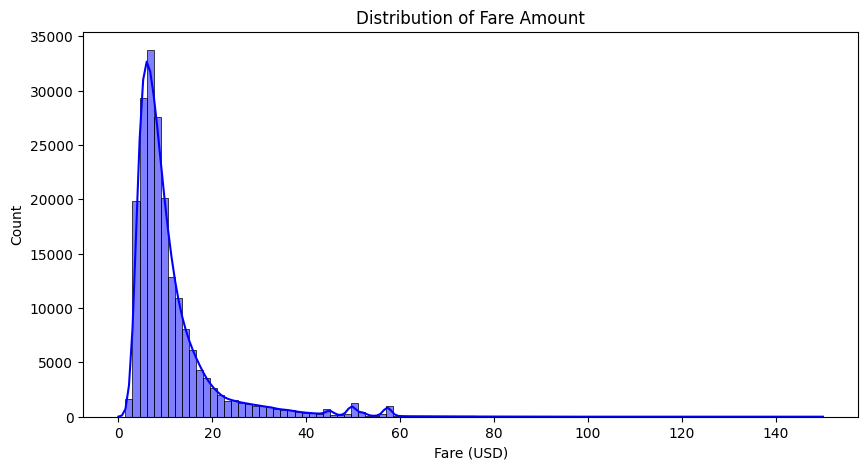

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['fare_amount'], bins=100, kde=True, color='blue')
plt.title('Distribution of Fare Amount')
plt.xlabel('Fare (USD)')
plt.ylabel('Count')
plt.show()

### Passenger Count Distribution

C:\Users\EL10_gazy\AppData\Local\Temp\ipykernel_21980\2818906478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='passenger_count', data=df, palette='Set2')


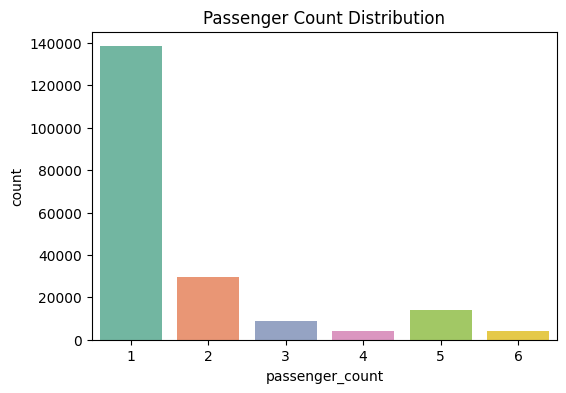

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x='passenger_count', data=df, palette='Set2')
plt.title('Passenger Count Distribution')
plt.show()

### Parse datetime properly

In [14]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df.info()

<class 'pandas.DataFrame'>
Index: 199245 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        199245 non-null  float64            
 1   pickup_datetime    199245 non-null  datetime64[us, UTC]
 2   pickup_longitude   199245 non-null  float64            
 3   pickup_latitude    199245 non-null  float64            
 4   dropoff_longitude  199245 non-null  float64            
 5   dropoff_latitude   199245 non-null  float64            
 6   passenger_count    199245 non-null  int64              
dtypes: datetime64[us, UTC](1), float64(5), int64(1)
memory usage: 12.2 MB


In [15]:
df.shape

(199245, 7)

### Remove invalid/garbage coordinates (NYC bounding box)

In [16]:
df = df[
    df['pickup_longitude'].between(-75, -72) &
    df['dropoff_longitude'].between(-75, -72) &
    df['pickup_latitude'].between(39, 42) &
    df['dropoff_latitude'].between(39, 42)
]



### Drop rows where pickup =dropoff (zero-distance trips)

In [17]:
df = df[~((df['pickup_latitude'] == df['dropoff_latitude']) &
          (df['pickup_longitude'] == df['dropoff_longitude']))]

df.reset_index(drop=True, inplace=True)
print(df.shape)

(193072, 7)


### Compute Trip Distance 

In [18]:

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df['trip_distance_km'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance_km
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450


### calculate Bearing (direction of travel)

In [19]:
def calculate_bearing(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    bearing = np.degrees(np.arctan2(x, y))
    return (bearing + 360) % 360

df['bearing'] = calculate_bearing(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance_km,bearing
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,179.124609
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,359.302804
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,45.254124
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,33.192997
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,295.254931


### Distance from City Center

In [20]:
NYC_CENTER = (40.7128, -74.0060)  # Manhattan reference point

df['pickup_dist_from_center'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'], *NYC_CENTER
)
df['dropoff_dist_from_center'] = haversine(
    df['dropoff_latitude'], df['dropoff_longitude'], *NYC_CENTER
)

### Time-Based Features

In [21]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek  # 0=Mon
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = df['hour'].apply(lambda h: 1 if (7 <= h <= 9 or 16 <= h <= 19) else 0)

### Correlation with target

In [22]:
corr = df.corr(numeric_only=True)['fare_amount'].sort_values(ascending=False)
print(corr)

fare_amount                 1.000000
trip_distance_km            0.801717
pickup_longitude            0.414234
dropoff_dist_from_center    0.328492
dropoff_longitude           0.305738
pickup_dist_from_center     0.303226
year                        0.121740
bearing                     0.055194
month                       0.024767
passenger_count             0.012680
day_of_week                 0.005283
is_weekend                 -0.001038
hour                       -0.020547
is_rush_hour               -0.020991
dropoff_latitude           -0.157127
pickup_latitude            -0.192590
Name: fare_amount, dtype: float64


In [23]:
df.drop(columns=['pickup_datetime'], inplace=True)  # already extracted what we need

### Feature Selection

In [24]:
from sklearn.feature_selection import mutual_info_regression

X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print(mi_series)

trip_distance_km            0.925037
year                        0.471050
dropoff_longitude           0.128465
dropoff_latitude            0.117001
dropoff_dist_from_center    0.112747
pickup_dist_from_center     0.104294
pickup_longitude            0.102932
bearing                     0.097909
pickup_latitude             0.087423
hour                        0.018532
month                       0.016029
passenger_count             0.006122
is_rush_hour                0.005372
is_weekend                  0.004593
day_of_week                 0.003707
dtype: float64


In [28]:
df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance_km,bearing,pickup_dist_from_center,dropoff_dist_from_center,hour,day_of_week,month,year,is_weekend,is_rush_hour
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,179.124609,2.888822,1.280903,19,3,5,2015,0,1
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,359.302804,1.976096,4.279659,20,4,7,2009,0,0
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,45.254124,3.111167,7.594400,21,0,8,2009,0,0
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,33.192997,9.035634,10.635729,8,4,6,2009,0,1
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,295.254931,7.659096,6.059087,17,3,8,2014,0,1


In [30]:
df.to_csv('uber_processed.csv', index=False)